[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/adohertymunro/DS-31095-Final-Project/blob/main/Final%20Project.ipynb)

$$\textbf{A Hedonic Pricing Model of Park Access in Chicago, IL}$$

$$\text{Andrew Doherty Munro}$$

$$\text{DS} 30195 - \text{Data and the State}$$

$\textbf{Research Question and Motivation}$

I love being outside, and one thing I love about Chicago is its great parks - one of my favorite things to do in Hyde Park is to spend time at the Point and sit by the water. But how valuable is that access to me? While it's great to have access to greenspace, it's hard to actually quantify how valuable a person finds that access. This project seeks to investigate how much people value parks by leveraging extensive data collected on Chicago's parks by the Trust for Public Land, as well as American Community Survey 5-year Data on tract-level characteristics like mean age of housing, number of bedrooms, etc. to parse out the effect that distance to a park has on tract-level housing prices.

$\textbf{Background, Literature Review, and Data}$

This project will leverage a Hedonic Pricing Model, which is well-established in the urban studies community to evaluate the effect of urban greenspace on real estate prices. The idea underlying such a model is "revealed preferences," where the amount a given individual values something (like access to an urban park) is $\textit{revealed}$ by the amount they are willing to pay for it. Thus, if higher housing prices are associated with access to greenspace (holding other factors constant), one can reasonably surmise that people are generally willing to pay for such a privilege.

This model has been applied to several cities in several contexts. A "proximate principle" - the idea that proximity to a park is valuable - has been present as far back as the 1800s in England, and was expanded upon in hedonic price theory which "proposed that utility was derived from the characteristics or attributes of goods" (Crompton 2005). Analyzing existing research investigating whether such a model applies to in the U.S. context, Crompton finds that the evideence "unequivocally supports" the argument that proximity to greenspace increases property values ($\textit{id.}$).

Several studies have investigated this relationship in granular detail. Although greenspace is typically seen as a public good, if crime in a given area is sufficiently high it can instead become a locus for behavior property owners may find distasteful. Indeed, an investigation of Baltimore found a "flipping point" - typically between 400-500% of the national average of a robbery and rape index - at which the relationship reverses, and proximity to a park decreases housing prices (Troy and Grove 2008). Furthermore, the nature of the park can matter. An application to Brisbane found that while access to a $\textit{recreational}$ park had the typical appreciative affect on home prices, proximity to a $\textit{sports}$ park actually decreased home values (Bottero et al. 2022). Size, characteristic, and distance of a park all matter - types of green space with higher ratings in terms of accessibility and maintenance have been found to have higher implicit prices (Chen et al. 2022). Finally, some evidence shows that houses with "easy access" to urban parks actually see a price $\textit{reduction}$. While obviously positive in many respects, urban parks also come with "disamenities" such as noise, foot traffic congestion, and the like; an analysis of the city of Shenzen, China found that access reduced housing values by approximately 2-percent. 

With such hetergenous findings in diverse contexts, it's therefore an open question as to what relationship is present in a city such as Chicago. To investigate, I rely on two main data sources. The Trust for Public Land (TPL) provides public data on U.S. parks that includes geography, demographic information, and park characteristics as part of its U.S. ParkServe Dataset. I also leverage American Community Survey 5-Year estimates for Cook County to get housing characteristics in a given Census tract. Thus, I have rich demographic, real estate, and geographic information on Chicago and its parks with which to perform my analysis. One important thing to note: TPL provides only current-year data, and does not publicly archive past shapefiles. Thus, there is a small data mismatch: I use 2026 boundaries for Chicago parks, but 2024 ACS estimates. This is likely roughly the same as aligning the two, as urban parks in a dense city like Chicago are difficult to grow or shrink in any meaningful capacity, but it's something to be cognizant of.

$\textbf{Initial Results and Data Exploration}$

To begin, I want to explore the nature and characteristics of Chicago's Parks. For now, I am using Cook County as the definition of "Chicago," as the data from the Trust for Public Land includes counties and metropolitan areas, and Cook County is generally more informative than the Chicago metropolitan area, which extends to Indiana. Thus, from here on I refer to Cook County as "Chicago."

In [522]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from census import Census
import statsmodels.api as sm
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from esda import Moran, Moran_Local
from splot.esda import moran_scatterplot, lisa_cluster
import libpysal

#ignore runtime errors to avoid cluttering output (they don't affect anything)
warnings.filterwarnings("ignore", category=RuntimeWarning)

#fetch Census API key
census_key = os.environ.get("CENSUS_API_KEY")
if not census_key:
    print('Something went wrong with Census Key fetching')

Load in generic "Parks" shapefile, subset to Chicago and project to Illinois State Plane East CRS:

In [523]:
parks = gpd.read_file(r'DS30195 Data/shapefiles/Parks.shp')

chicago_parks = parks[(parks['Park_State'] == 'Illinois') & (parks['Park_Count'] == 'Cook County')]
chicago_parks = chicago_parks.to_crs(epsg=26971)

Plot to get a sense of coverage:

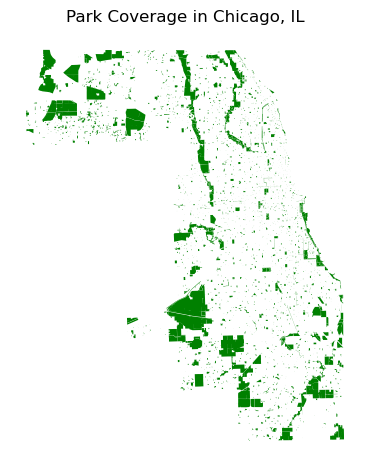

In [524]:
fig, ax = plt.subplots(1, 1)

chicago_parks.plot(color='green', ax=ax)

ax.set_axis_off()
ax.set_title('Park Coverage in Chicago, IL')

plt.tight_layout()
plt.show()

Land Trust also Includes a shapefile with helpful statistics attached to each park. However, it doesn't include counties! So a spatial join with the previous shapefile is necessary to get all the info at the county level:

In [525]:
park_stats = gpd.read_file(r'DS30195 Data/shapefiles/Parks_Statistics.shp')
park_stats = park_stats.to_crs(chicago_parks.crs)

#strip out duplicate columns for merging
cols_to_keep = []

for col in park_stats.columns.to_list():
    if col not in chicago_parks.columns.to_list():
        cols_to_keep.append(col)
    elif col == 'geometry':
        cols_to_keep.append(col)

park_stats = park_stats[cols_to_keep]

chicago_parks_full = chicago_parks.sjoin(park_stats,
                                how='left',
                                predicate='intersects')

chicago_parks_full.head()

,ParkID,GISTrkrID,SourceID,Park_Name,Park_Desig,Park_Owner,Park_Local,Park_Manag,Park_Loc_1,Park_Acces,...,SUM_TOTHHS,SUM_WHITE_,SUM_BLACK_,SUM_AMERIN,SUM_ASIAN_,SUM_PACIFI,SUM_OTHRAC,SUM_RACE2U,SUM_HISP_S,Park_Pla_1
34264,1701010-0001,3692,1,Laramie Park,LP,SPECIAL_DISTRICT,ALSIP PARK DIST,SPECIAL_DISTRICT,ALSIP PARK DIST,3,...,477.0,842.0,119.0,3.0,41.0,1.0,2.0,28.0,339.0,1701010
34265,1701010-0002,3692,2,Kiwanis Park,LP,MUNI,VILLAGE OF ALSIP,MUNI,VILLAGE OF ALSIP,3,...,464.0,763.0,114.0,3.0,37.0,1.0,1.0,24.0,312.0,1701010
34266,1701010-0003,3692,3,Freedom Park,LP,SPECIAL_DISTRICT,METRO WATER RECLM DIST,SPECIAL_DISTRICT,METRO WATER RECLM DIST,3,...,486.0,560.0,224.0,1.0,30.0,0.0,1.0,26.0,313.0,1701010
34267,1701010-0004,3692,4,Ketelaar Tot Lot,LP,SPECIAL_DISTRICT,ALSIP PARK DIST,SPECIAL_DISTRICT,ALSIP PARK DIST,3,...,189.0,162.0,130.0,0.0,12.0,0.0,3.0,13.0,204.0,1701010
34268,1701010-0005,3692,5,Lacrosse Tot Lot,LP,SPECIAL_DISTRICT,ALSIP PARK DIST,SPECIAL_DISTRICT,ALSIP PARK DIST,3,...,191.0,227.0,44.0,1.0,11.0,0.0,0.0,7.0,99.0,1701010


How many parks are there in Cook County?

In [526]:
print('There are', len(chicago_parks_full), 'parks in Cook County')

There are 3176 parks in Cook County


There is an "Area" column, but it's not clear what the units are, which warrants investigation:

In [527]:
#Illinois State Plane East uses meters for area, so take that and convert to acres:
chicago_parks_full['area_sqm'] = chicago_parks_full.geometry.area
chicago_parks_full['area_acres'] = chicago_parks_full.geometry.area * 0.000247105

chicago_parks_full[['area_sqm', 'area_acres', 'Park_Size_']].head()

,area_sqm,area_acres,Park_Size_
34264,9738.849271,2.406518,2.406503
34265,6745.211133,1.666775,1.666764
34266,10157.568842,2.509986,2.509964
34267,2182.226756,0.539239,0.539231
34268,727.544414,0.179780,0.179778


It looks like "Park_Size_" measures acres! Now we can ask where/what the biggest parks are. There are a lot of parks (over 3,100!), so a reasonable sample is the top 5%, or about 150 parks.

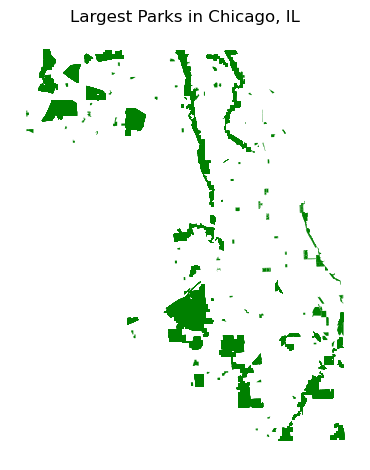

In [528]:
top_5p = np.quantile(chicago_parks_full['Park_Size_'], q=0.95)

biggest_parks = chicago_parks_full[chicago_parks_full['Park_Size_'] >= top_5p]

fig, ax = plt.subplots(1, 1)

biggest_parks.plot(color='green', ax=ax)

ax.set_axis_off()
ax.set_title('Largest Parks in Chicago, IL')

plt.tight_layout()
plt.show()

Some of these are quite large, but others aren't as massive, and they're pretty spread out so there's good variation. Who has access to these parks? Can start by using the included income statistics, which TPL includes. All statistics are represented by people who live within a 10-minute walk to a given park, which serves as a proxy of access.

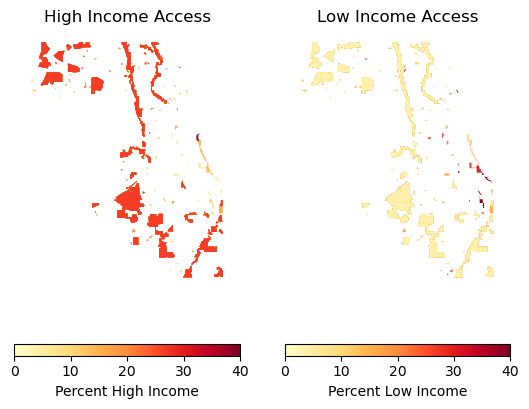

In [529]:
chicago_parks_full['pct_high_inc'] = 100* chicago_parks_full['SUM_HHIHIG'] / chicago_parks_full['SUM_TOTPOP']
chicago_parks_full['pct_low_inc'] = 100 * chicago_parks_full['SUM_HHILOW'] / chicago_parks_full['SUM_TOTPOP']

#refilter to biggest parks so that it includes new columns
biggest_parks = chicago_parks_full[chicago_parks_full['Park_Size_'] >= top_5p]

fig, (ax1, ax2) = plt.subplots(1, 2)

biggest_parks.plot(
    column='pct_high_inc',
    ax=ax1,
    legend=True,
    cmap='YlOrRd',
    legend_kwds={'label': 'Percent High Income',
                 'orientation': 'horizontal'},
    vmin=0,
    vmax=40
)

biggest_parks.plot(
    column='pct_low_inc',
    ax=ax2,
    legend=True,
    cmap='YlOrRd',
    legend_kwds={'label': 'Percent Low Income',
                 'orientation': 'horizontal'},
    vmin=0,
    vmax=40
)

ax1.set_title('High Income Access')
ax2.set_title('Low Income Access')
ax1.set_axis_off()
ax2.set_axis_off()

plt.show()

There's a huge discrepancy! Taking the largest parks, it seems like high income people (as measured by earning >125% of median income) are much more likely to be near parks.

Another interesting thing that TPL tracks is in a separate .csv, called "canopy pct". This measures what percentage of the area of a park is canopy, or covered by trees.

In [530]:
add_stats = pd.read_csv('DS30195 Data/shapefiles/AdditionalData.csv')

chicago_parks_full = chicago_parks_full.merge(add_stats, on='ParkID', how='left')

There's a pretty significant outlier:

In [531]:
chicago_parks_full['canopy_pct'].max()

np.float64(249.27074255109775)

Which is likely just measurement error, but worth investigating. This code will look at all parks where "canopy percent" is greater than 100:

In [532]:
print(chicago_parks_full[chicago_parks_full['canopy_pct'] > 100][['Park_Size_', 'canopy_pct']])

      Park_Size_  canopy_pct
2944    0.033552  101.811237
3108    0.001142  249.270743


These parks are super super small (the park with a percent canopy coverage of 249% is only 0.001 acres!) so this is likely just measurement error and these parks can be omitted going forward.

In [533]:
chicago_parks_full = chicago_parks_full[chicago_parks_full['canopy_pct'] <= 100]

Now, is canopy coverage associated with income? Given that there are many tracts, a typical scatterplot is going to be incredibly hard to visualize. Thus, I'm going to use a kernel density estimate plot overlay with a line of best fit using the seaborn package in this graph and all similar graphs moving forward.

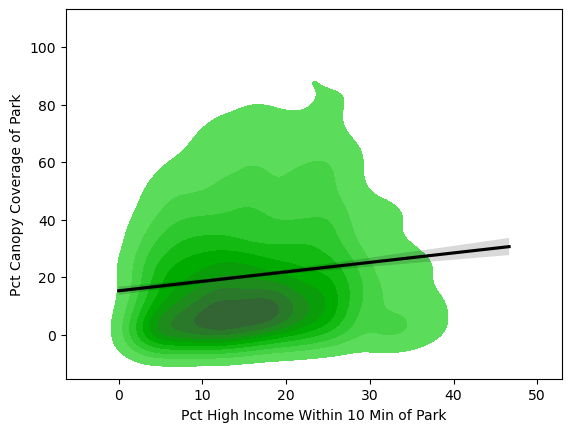

In [534]:
fig, ax = plt.subplots(1, 1)

sns.kdeplot(
    ax=ax,
    data = chicago_parks_full,
    x='pct_high_inc',
    y='canopy_pct',
    color='green',
    fill=True
)

sns.regplot(
    ax=ax,
    data = chicago_parks_full,
    x='pct_high_inc',
    y='canopy_pct',
    scatter=False,
    line_kws={'color': 'black'}
    )

ax.set_xlabel('Pct High Income Within 10 Min of Park')
ax.set_ylabel('Pct Canopy Coverage of Park')

plt.show()

It seems like there's something there! But even if income increases with canopy coverage (which is a reasonable proxy for how "nice" a greenspace is), it's not clear whether these individuals are "paying" for such access, just that the two variables are associated with one another.

$\textbf{Are Parks Related to Housing Prices?}$

Now to investigate housing prices and parks in Chicago. The Census includes Median Housing Price as part of its ACS 5-year estimates, with the most granular unit of analysis being the block level. Given how large cook county is, and the fact that block groups tend to be at most a few thousand people, I opt to use tracts instead given that they will have better data due to larger sample size of respondents.

The below pulls in Census data using a typical API call and does some cleaning:

In [535]:
year = 2024

if census_key == "":
    raise ValueError("You need to provide a Census API key to run this code. You can get one for free at https://api.census.gov/data/key_signup.html")

census = Census(key=census_key, year=year)

VARIABLES = {
    "NAME": "name",
    "B25077_001E": "median_home_value",
    "B01003_001E": "total_population",
    "B15003_001E": "pop_25_plus",
    "B15003_022E": "bachelors",
    "B15003_023E": "masters",
    "B15003_024E": "professional",
    "B15003_025E": "doctorate",
    "B03002_003E": "pop_non_hispanic_white",
    "B03002_004E": "pop_black",
    "B03002_012E": "pop_hispanic",
    "B19013_001E": "median_household_income",
    "B25035_001E": "median_year_built",
    "B25002_002E": "occupied_units",
    "B25001_001E": "total_housing_units",
    #pull count of housing units by room count for rooms/unit calculation
    "B25017_002E": "rooms_1",
    "B25017_003E": "rooms_2",
    "B25017_004E": "rooms_3",
    "B25017_005E": "rooms_4",
    "B25017_006E": "rooms_5",
    "B25017_007E": "rooms_6",
    "B25017_008E": "rooms_7",
    "B25017_009E": "rooms_8",
    "B25017_010E": "rooms_9plus",
}

try:
    data = census.acs5.get(
        tuple(VARIABLES.keys()),
        geo={
            "for": "tract:*",
            "in": "state:17 county:031"
        }
    )

except Exception as e:
    print(f"Request failed: {e}")

census_data = pd.DataFrame(data)

Clean this data/calculate relevant rates:

In [536]:
for column in ['state', 'county', 'tract']:
    census_data[column] = census_data[column].astype(str)

census_data['GEOID'] = census_data['state'] + census_data['county'] + census_data['tract']

census_data = census_data.rename(columns=VARIABLES)

#calculate percent with at least a Bachelors
educ_cols = ['bachelors', 'masters', 'professional', 'doctorate']

census_data['bach_plus'] = census_data[educ_cols].sum(axis=1)
census_data['perc_bach'] = census_data['bach_plus'] / census_data['pop_25_plus']

#calculate percent of each race
races = ['non_hispanic_white', 'black', 'hispanic']

for race in races:
    key = 'pop_' + race
    col = 'pct_' + race

    census_data[col] = census_data[key] / census_data['total_population']

#approximate "rooms per unit" (proxy of housing size) by a weighted average. need total rooms / total occupied units
census_data['estimated_total_rooms'] = (
    1 * census_data['rooms_1'] +
    2 * census_data['rooms_2'] +
    3 * census_data['rooms_3'] +
    4 * census_data['rooms_4'] +
    5 * census_data['rooms_5'] +
    6 * census_data['rooms_6'] +
    7 * census_data['rooms_7'] +
    8 * census_data['rooms_8'] +
    #conservatively say "9+" rooms indicates 9 rooms
    9 * census_data['rooms_9plus']
)

census_data['rooms_per_unit'] = census_data['estimated_total_rooms'] /census_data['occupied_units']

#finally, calculate occupancy rate
census_data['occupancy_rate'] = census_data['occupied_units'] / census_data['total_housing_units']

#drop extra columns
cols_to_drop = [
    'name', 'state', 'estimated_total_rooms',
    'county', 'tract', 'bachelors',
    'masters', 'professional', 'doctorate', 
    'bach_plus', 'occupied_units', 'total_housing_units',
    'rooms_1', 'rooms_2', 'rooms_3',
    'rooms_4', 'rooms_5', 'rooms_6',
    'rooms_7', 'rooms_8', 'rooms_9plus',

    ]

census_data = census_data.drop(cols_to_drop, axis=1)

census_data.head()

,median_home_value,total_population,pop_25_plus,pop_non_hispanic_white,pop_black,pop_hispanic,median_household_income,median_year_built,GEOID,perc_bach,pct_non_hispanic_white,pct_black,pct_hispanic,rooms_per_unit,occupancy_rate
0,340700.0,4198.0,3169.0,1638.0,1632.0,645.0,74145.0,1938,17031010100,0.457873,0.390186,0.388757,0.153645,5.222855,0.786231
1,239900.0,7361.0,4678.0,1287.0,2147.0,3137.0,63056.0,1946,17031010201,0.330697,0.174840,0.291672,0.426165,4.741925,0.907204
2,338000.0,2482.0,1985.0,863.0,664.0,656.0,53220.0,1956,17031010202,0.467506,0.347703,0.267526,0.264303,4.215979,0.872129
3,248500.0,6477.0,5375.0,3091.0,1107.0,1588.0,73105.0,1941,17031010300,0.496372,0.477227,0.170912,0.245175,4.334567,0.948246
4,231100.0,4545.0,2671.0,3338.0,254.0,255.0,54083.0,1942,17031010400,0.618495,0.734433,0.055886,0.056106,4.385422,0.856385


Merge in Census Tract TIGER File:

In [537]:
tracts = gpd.read_file(r'DS30195 Data/shapefiles/Census Tracts/tl_2024_17_tract.shp')

housing_gdf = tracts.merge(census_data,
                           how='right',
                           on='GEOID',
                           indicator=True)

assert len(housing_gdf[housing_gdf['_merge'] == 'both']) == len(housing_gdf)

housing_gdf = housing_gdf.drop('_merge', axis=1)

In [538]:
housing_gdf = gpd.GeoDataFrame(housing_gdf, geometry='geometry')
housing_gdf = housing_gdf.to_crs(chicago_parks_full.crs)

#filter out tracts with no population, as we care about places where people actually live:
housing_gdf = housing_gdf[housing_gdf['total_population'] != 0]

To start, I'm going to look at the closest park for a given census tract, which I'll achieve by doing a dissolve operation. I'll then do an operation to calculate how far a given census tract is from its closest park, as measured by its centroid's distance from the dissolved park. This is a rough approximation of park access for the inhabitants of a tract.

In [539]:
one_big_park = chicago_parks_full.dissolve()

housing_gdf['park_dist'] = (
    housing_gdf.copy().geometry.centroid
    .distance(one_big_park.copy().geometry.iloc[0])
)

If plotting just park distance, there are two significant outliers in the western area of the county that skew the scale significantly and hide a lot of variation. Below I investigate two different ways to address this. The first is to simply omit the top 5 census tracts by distance to park so we can see the variation for the rest of the county. The other strategy is to use a log scale; here, the log1p() function from the numpy library is useful, as it adds 1 to every value so that 0s don't return NaN/-Inf, but rather return 0 given that log1 = 0.

In [540]:
#log park distance
housing_gdf['logged_park_dist'] = np.log1p(housing_gdf['park_dist'])

#omit census tracts in the top 5 of distance to nearest park
threshold = housing_gdf['park_dist'].nlargest(5).min()
trimmed_parks = housing_gdf[housing_gdf['park_dist'] < threshold]

Next, plot these side by side to get a fuller picture of how park access is distributed in Cook County:

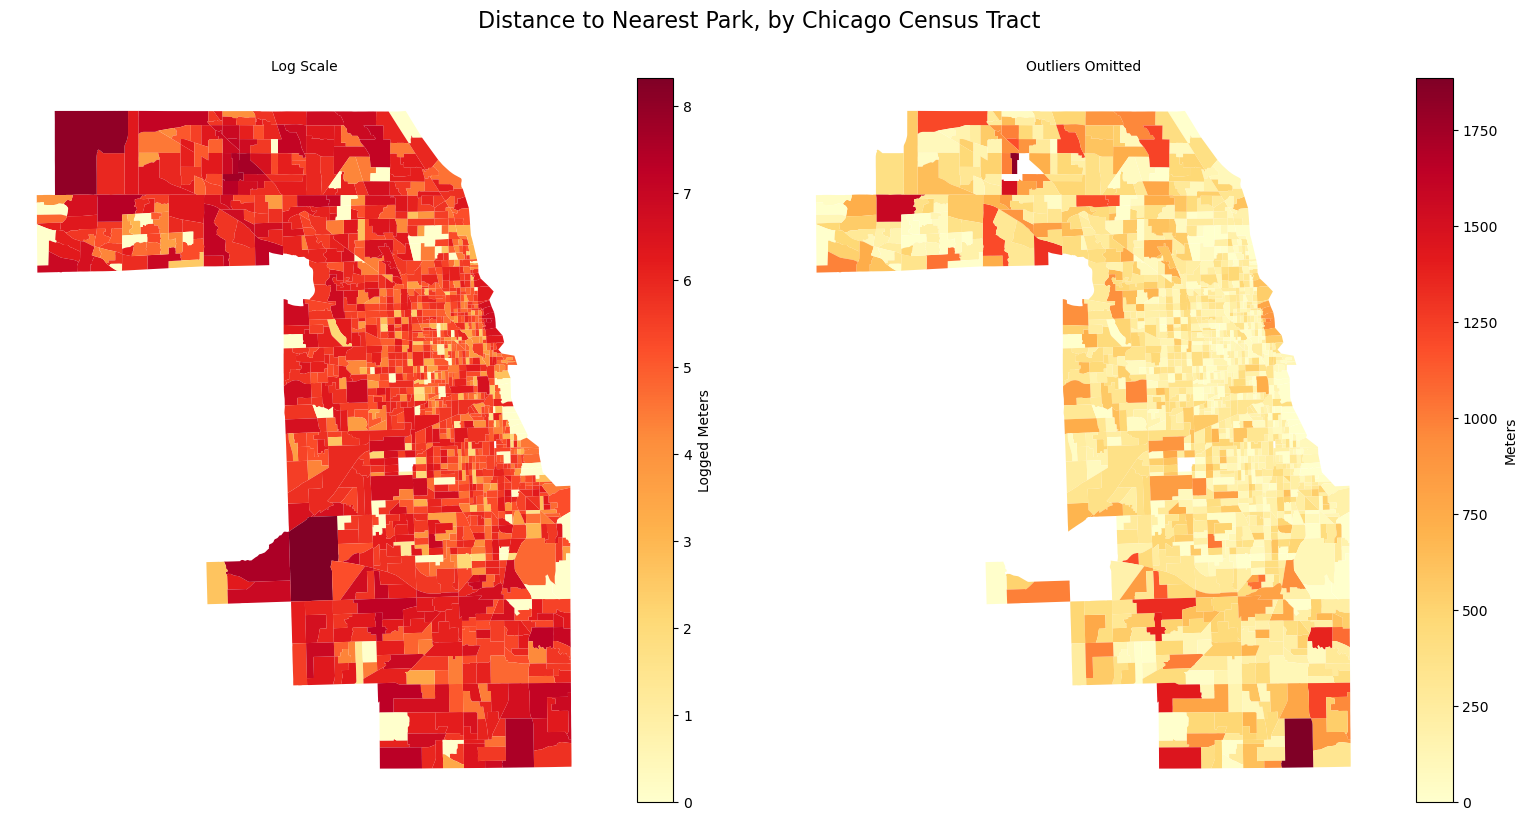

In [541]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

housing_gdf.plot(
    ax=ax1,
    column='logged_park_dist',
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'Logged Meters'}
)

trimmed_parks.plot(
    ax=ax2,
    column='park_dist',
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'Meters'}
)

ax1.set_axis_off()
ax1.set_title('Log Scale', fontsize=10)

ax2.set_axis_off()
ax2.set_title('Outliers Omitted', fontsize=10)

fig.suptitle('Distance to Nearest Park, by Chicago Census Tract', fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

Advantages and disadvantages are apparent. While logging preserves outliers - which are signficant - it also hides a lot of variation given that the actual scale is not that large. It will thus make differences in park access seem smaller than they actually are. Preserving the raw scale shows that most tracts are reasonably close to a park, with some "deserts" on the south and north sides of the county. In conjunction they provide a relatively complete picture of the distribution of parks across the county.

Another strategy is to omit the geographic element and just plot the distribution of the metric:

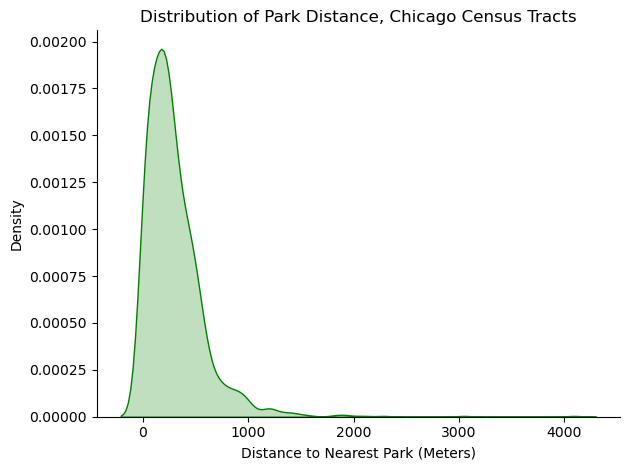

In [542]:
fig, ax = plt.subplots(1, 1)

sns.kdeplot(
    ax=ax,
    data=housing_gdf,
    x='park_dist',
    color='green',
    fill=True
)

sns.despine()

ax.set_xlabel('Distance to Nearest Park (Meters)')
ax.set_title('Distribution of Park Distance, Chicago Census Tracts')

plt.tight_layout()
plt.show()

This shows that almost all census tracts have a park within 0-1000 meters, with the same significant outliers seen above in the distribution's very long right tail.

Given that there is reasonably good variation in park access (as measured by distance to nearest park as the crow flies), analyzing its effect on housing prices is doable. I'll measure this by distance to any park (calculated above) and distance to a large park (classified the same as before as a park in the top 5% of area). To begin, omit any tracts where Home Value is coded as missing (which in this case is -666666666), as well as income for good measure, as tracts with missing income likely aren't very useful, and calculate distance to a large park. Then, make a simple regression plots to see the relationship between these distance measures and house price. I also omit the outliers as above, since it makes plotting much more effective and it's (generally) ok to condition on an independent variable and the presence of these outliers has the potential to really skew analysis.

Investigating distance to any park and the largest parks is useful to investigate the relationships that previous studies have found. Large parks tend to be associated with higher foot traffic, more noise, and the like - distinguishing between any park and large parks thus teases out whether these parks exhibit negative externalities as measured through housing price.

In [543]:
housing_gdf = housing_gdf[(housing_gdf['median_home_value'] > 0) & (housing_gdf['median_household_income'] > 0) & (housing_gdf['park_dist'] < threshold)]

largest_parks = biggest_parks.dissolve()

housing_gdf['large_park_dist'] = (
    housing_gdf.copy().geometry.centroid
    .distance(largest_parks.copy().geometry.iloc[0])
)

c:\Users\andre\miniconda3\envs\DAP\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Plot distance to a large park to see if there are any interesting patterns:

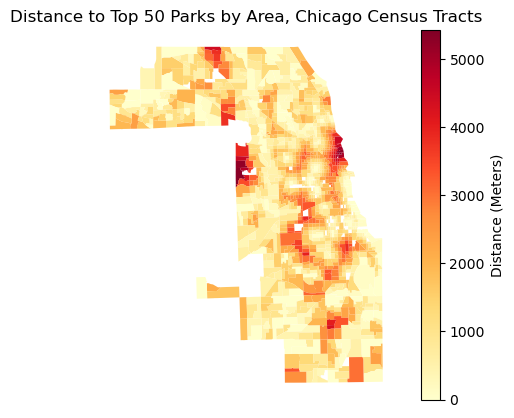

In [544]:
fig, ax = plt.subplots(1, 1)

housing_gdf.plot(
    ax=ax,
    column='large_park_dist',
    legend=True,
    cmap='YlOrRd',
    legend_kwds={'label': 'Distance (Meters)'}
)

ax.set_axis_off()
ax.set_title('Distance to Top 50 Parks by Area, Chicago Census Tracts')

plt.show()

There's much stronger spatial correlation for large park access, which is logical; by definition, the largest parks are going to be scarcer and similarly far away from neighboring census tracts. Now, investigate the relationship between distance (by each metric) and housing prices:

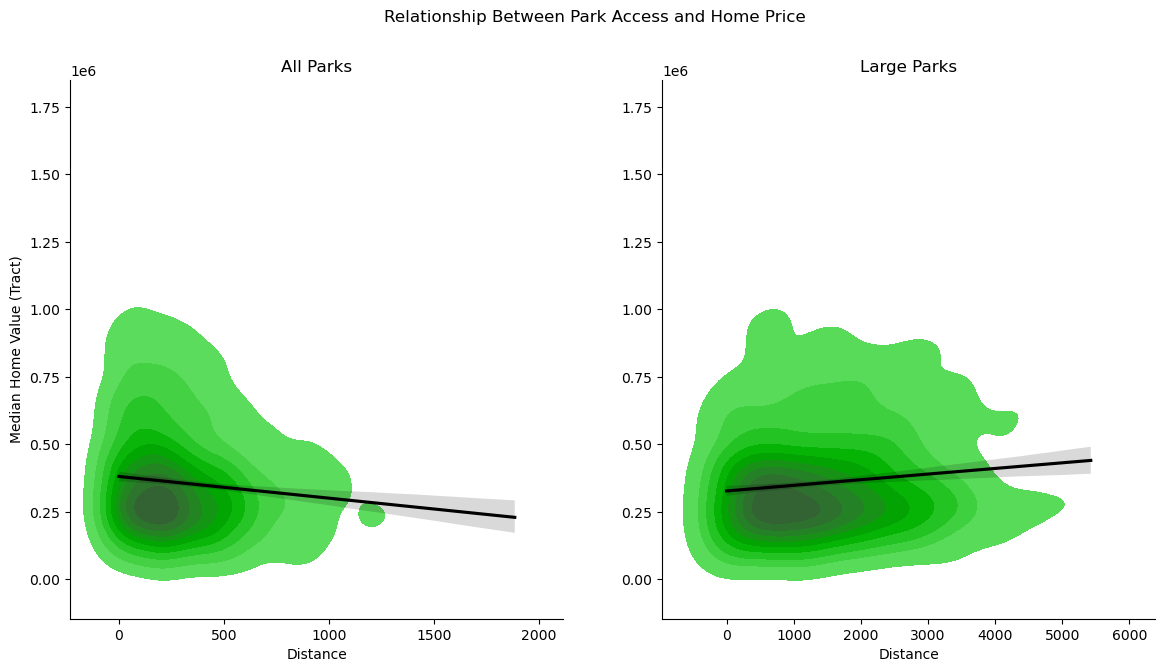

In [545]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))


sns.kdeplot(
    ax=ax1,
    data=housing_gdf,
    x='park_dist',
    y='median_home_value',
    color='green',
    fill=True
)

sns.regplot(
    ax=ax1,
    data = housing_gdf,
    x='park_dist',
    y='median_home_value',
    line_kws={'color': 'black'},
    scatter=False)

sns.kdeplot(
    ax=ax2,
    data=housing_gdf,
    x='large_park_dist',
    y='median_home_value',
    color='green',
    fill=True
)

sns.regplot(
    ax=ax2,
    data=housing_gdf,
    x='large_park_dist',
    y='median_home_value',
    line_kws={'color': 'black'},
    scatter=False
)

sns.despine()

ax1.set_xlabel('Distance')
ax1.set_ylabel('Median Home Value (Tract)')
ax1.set_title('All Parks')

ax2.set_xlabel('Distance')
ax2.set_title('Large Parks')
ax2.set_ylabel('')


fig.suptitle('Relationship Between Park Access and Home Price')

plt.show()

An interesting patterns emerges; while a shorter distance to $\textit{any}$ park is associated with higher home prices - suggesting individuals are willing to "pay" for access - a shorter distance to a $\textit{large}$ park is associated with lower home prices. Of course, a bivariate regression is not particularly informative when other variables could affect both housing prices and park access.

A hedonic pricing model as described previously is useful here. I specify such a model as follows:

$$price_i = \alpha + \beta_1 D_i + \sum_{k} \beta_k X_{ki} + \sum_{j} \gamma_j H_{ji} + \sum_{n} \delta_n P_{ni} + \epsilon_i$$

Where $D_i$ is a given measure of distance for a given tract $\textit{i}$, $X_k$ is a given demographic covariate (race, education, etc) $H_j$ is a given housing characteristic (year built, rooms, etc), and $P_n$ is a characteristic of a tract's nearest park. $\epsilon_i$ indexes noise, or the model's residuals. The usefulness of specifying such a model using Ordinary Least Squares is each coefficient has a $\textit{ceteris parabis}$ interpretation, meaning "all else equal." Thus, the coefficient on distance, $\beta_1$, will be how much distance to a park is reflected in housing prices holding all other characteristics constant.

Here, demographic covariates are shares of black, white, and hispanic population, percent with a bachelors, and median household income, all at the tract level. Housing characteristics are median year built, rooms per unit, and the occupancy rate of a given tract. I also include controls for park quality as percent canopy coverage and park area, as these may make housing desirable regardless of distance. All of these variables could reasonably affect housing prices other than through park distance, so it's important to control for them.

Begin by joining all data together:

In [546]:
chicago_parks_full = chicago_parks_full.drop('index_right', axis=1)

housing_parks_gdf = housing_gdf.sjoin_nearest(chicago_parks_full)

Run regression on distance to any park:

In [547]:
controls = ["pct_non_hispanic_white", "pct_black", "pct_hispanic", 
            "median_household_income", 'median_year_built', 'perc_bach', 
            'rooms_per_unit', 'occupancy_rate', 'canopy_pct', 'Park_Size_']

canopy_controls = [
    "pct_non_hispanic_white", "pct_black", "pct_hispanic", 
    "median_household_income", 'median_year_built', 'perc_bach', 
    'rooms_per_unit', 'occupancy_rate', 'park_dist', 'Park_Size_']

housing_parks_gdf['median_year_built'] = housing_parks_gdf['median_year_built'].astype(float)

all_formula = 'median_home_value ~ park_dist + ' + ' + '.join(controls)

all_parks_model = smf.ols(
    all_formula,
    data=housing_parks_gdf
).fit()

#store residuals for plotting later
dist_resid = smf.ols('park_dist ~ ' + ' + '.join(controls), data=housing_parks_gdf).fit().resid
canopy_resid = smf.ols('canopy_pct ~ ' + ' + '.join(canopy_controls), data=housing_parks_gdf).fit().resid
housing_parks_gdf['model_residuals'] = smf.ols('median_home_value ~ ' + ' + '.join(controls), data=housing_parks_gdf).fit().resid

And large parks:

In [548]:
biggest_formula = 'median_home_value ~ large_park_dist + ' + ' + '.join(controls)

biggest_model = smf.ols(
    biggest_formula,
    data=housing_parks_gdf
).fit()

#y residuals will be the same, as only our independent variable has changed:
big_x_resid = smf.ols('large_park_dist ~ ' + ' + '.join(controls), data=housing_parks_gdf).fit().resid

Display results (with only relevant variables displayed):

In [549]:
model_table = Stargazer([all_parks_model, biggest_model])

model_table.covariate_order([
    'park_dist',
    'large_park_dist',
    'canopy_pct',
    'Park_Size_'
])

model_table.rename_covariates({
    'park_dist': 'Distance, Any Park',
    'large_park_dist': 'Distance, Large Park',
    'canopy_pct': 'Nearest Park Canopy Coverage',
    'Park_Size_': 'Nearest Park Size (Acres)'
})

model_table.dependent_variable_name('Median Home Value')

model_table

These models yield interesting results - distance to any park is statistically signficant and has the expected negative sign, meaning that as distance to a park increases, housing values tend to decreases. Canopy coverage is also statistically significant and has a positive coefficient, meaning that individuals may value the aesthetic quality of their closest park (perhaps through things like views or neighborhood aesthetic). Interestingly, we no longer see a signficant relationship with distance to a large park, and park size is not signficant in either model.

An interesting way to view a relationship like this where there are lots of controls is a residualized plot - regress park distance on all controls, and regress home values on all controls, then regress the residuals or "errors" from each regression on each other. This is statistically identical to the multivariate regression above and is known as the Partial Regression or Frisch–Waugh–Lovell Theorem. Do this with park distance and canopy percentage below:

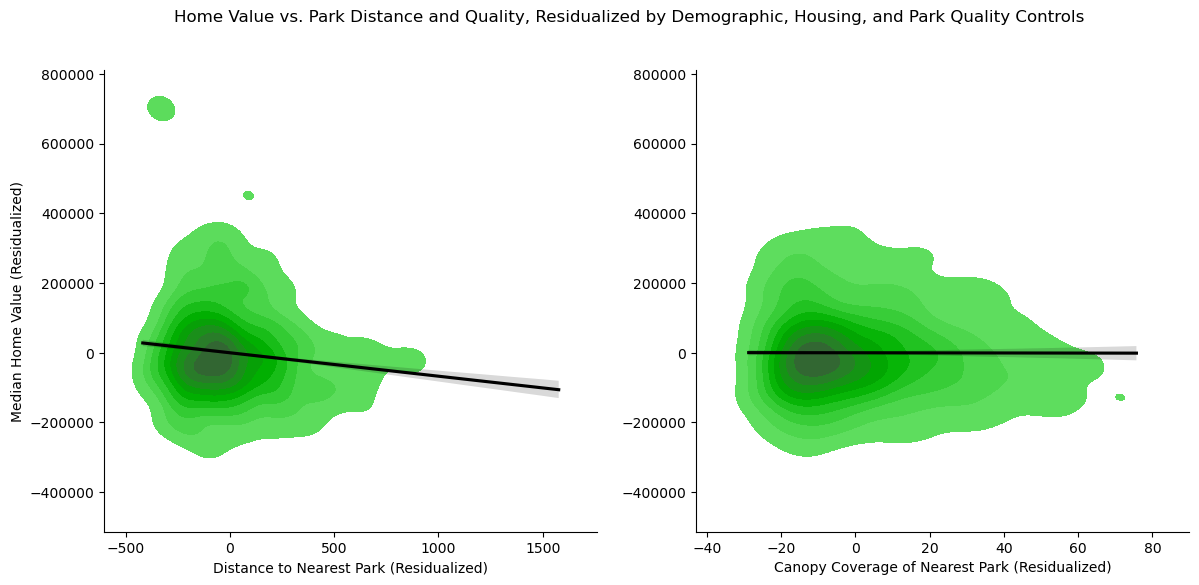

In [550]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


sns.kdeplot(
    ax=ax1,
    x=dist_resid,
    y=y_resid,
    fill=True,
    color='green'
)

sns.regplot(
    ax=ax1,
    x=dist_resid,
    y=y_resid,
    line_kws={'color': 'black'},
    scatter=False
)

sns.kdeplot(
    ax=ax2,
    x=canopy_resid,
    y=y_resid,
    fill=True,
    color='green'
)
sns.regplot(
    ax=ax2,
    x=canopy_resid,
    y=y_resid,
    line_kws={'color': 'black'},
    scatter=False
)

sns.despine()

ax1.set_ylabel('Median Home Value (Residualized)')
ax1.set_xlabel('Distance to Nearest Park (Residualized)')
ax2.set_xlabel('Canopy Coverage of Nearest Park (Residualized)')

fig.suptitle('Home Value vs. Park Distance and Quality, Residualized by Demographic, Housing, and Park Quality Controls')

plt.show()

This illustrates nicely the importance of interpreting a regression carefully. Park distance is measured in meters, so its coefficient of approximately -67 means that each additional meter to a tract's nearest park is associated with a 67 dollar decrease in median housing price. Thus, the difference between 0 meters and 1000 meters to the nearest park is 67,000 dollars in home value, which is quite signficant. Meanwhile, canopy coverage is a decimal, meaning it only ranges from 0 to 1. Thus changes the interpretation of the coefficient of 383 - that means the difference between a tract's nearest park having 0-percent coverage and 100-percent canopy coverage is only an additional 383 dollars in home value. So while this is $\textit{statistically}$ significant, there isn't much $\textit{practical}$ significance. In other words, while it may suggest individuals value canopy coverage, they don't seem to value it very much.

One last thing. When checking a model like the one above, it's useful to look at spatial autocorrelation - if the residuals, or the part unexplained by the regression model, exhibit strong spatial characteristics, it's likely the model needs some tweaking given that the same areas exhibit the same "unexplained" values. We can do this in two ways: Moran's I and a Local Indicator of Spatial Autocorrelation. I'll implement this with housing prices (which are almost certain to be spatially autocorrelated) and the regression residuals from the model using distance to any park. Comparing the two will be useful to see if the model improved on spatial concentration at all.

Begin with Moran's I, using a Queen relationship for weights:

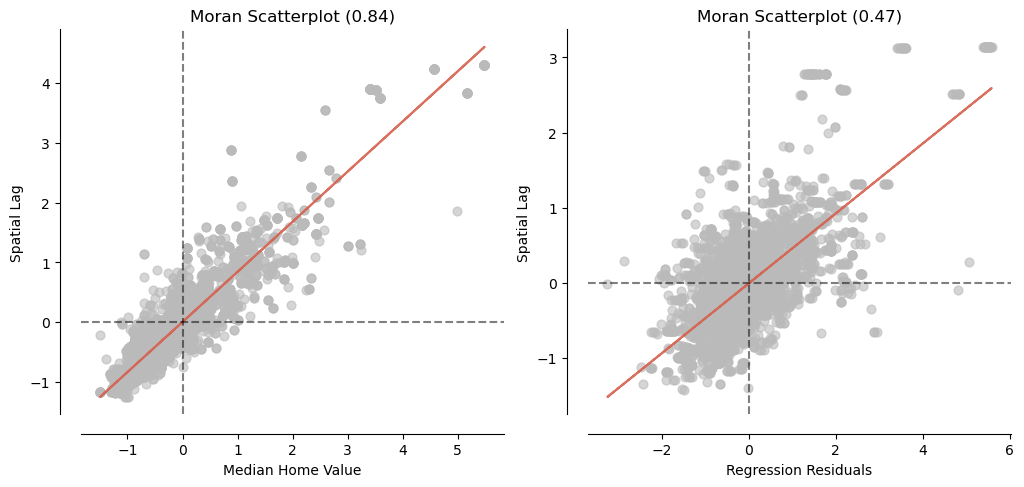

In [551]:
w = libpysal.weights.Queen.from_dataframe(housing_parks_gdf, use_index=False)
w.transform = 'r'

moran_homes = Moran(housing_parks_gdf['median_home_value'], w)
moran_resid = Moran(housing_parks_gdf['model_residuals'], w)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

moran_scatterplot(
    moran_homes,
    ax=ax1,
    aspect_equal=False
)

moran_scatterplot(
    moran_resid,
    ax=ax2,
    aspect_equal=False
)

ax1.set_xlabel('Median Home Value')
ax2.set_xlabel('Regression Residuals')

plt.show()


As expected, housing values are incredibly spatially correlated. Our residuals are as well, but to a lesser extent - a value of 0.47 rather than 0.84. So our model does ok with controlling for things relating to housing that show spatial patterns.

LISA also allows us to look at this visually, calculating a value for every tract rather than one value for the entire area like Moran's I does:

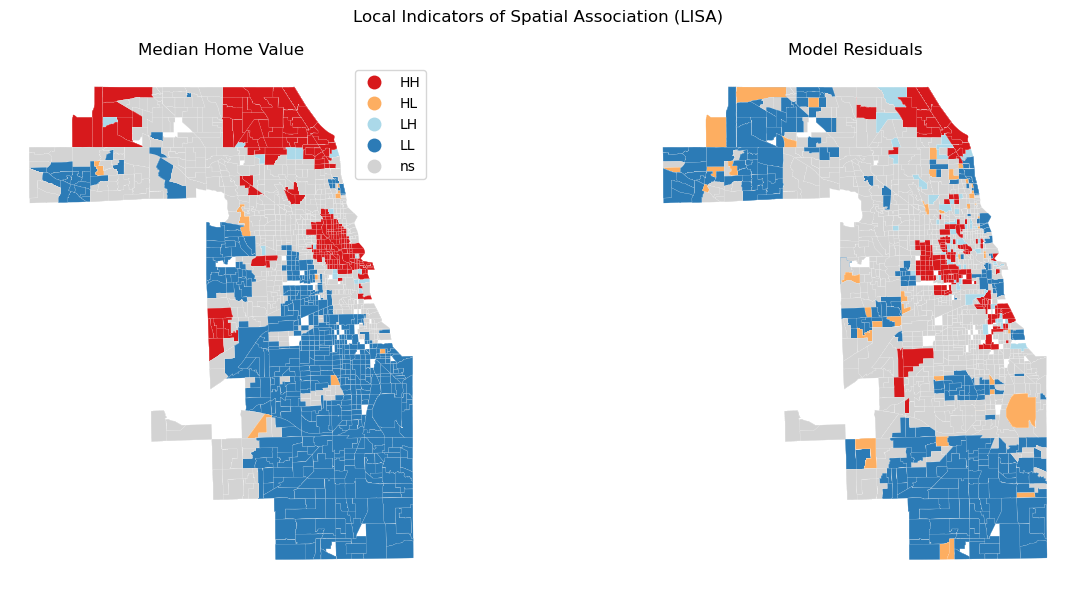

In [552]:
lisa_homes = Moran_Local(housing_parks_gdf['median_home_value'], w)
lisa_resid = Moran_Local(housing_parks_gdf['model_residuals'], w)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

lisa_cluster(
    lisa_homes, 
    housing_parks_gdf,
    ax=ax1)

lisa_cluster(
    lisa_resid, 
    housing_parks_gdf,
    ax=ax2,
    legend=False
)

ax1.set_title('Median Home Value')
ax2.set_title('Model Residuals')

fig.suptitle('Local Indicators of Spatial Association (LISA)')

plt.tight_layout()
plt.show()

We see some of the same patterns! Low-Low on the South Side and Northwest Side, which is to be expected, and High-High on the Northeast and Loop areas. Like we said above, it does seem that the model improves a bit on these spatial autocorrelations - the model residuals show much more grey areas indicating no correlation than median home values do. But looks like the model needs a bit of work before it's fully trustworthy.

$\textbf{Concluding Thoughts, Future Avenues}$

In sum, it looks like Chicago exhibits a lot of the same sorts of patterns existing literature has found in other contexts: home prices in Chicago seem to reflect people's willingness to pay to be near a park. While the model isn't perfect, as detailed previously, it provides some interesting patterns regarding how park distance and quality of park contribute to how much people tend to pay in a given census tract for homes.

This presents some interesting options for future research. To start, it would be useful to work with more granular data instead of a lot of medians and averages. Past studies have used housing $\textit{sales}$ rather than value to see how much people are actually paying for a real estate. Moreover, "big park" is a pretty poor proxy for some of the aspects I was hoping to test for (and is sensitive to the threshold chosen, in this case top 5-percent by area), like congestion and noise. Liu et al., as detailed in the literature review, leveraged cell-phone data in their study to see what the actual foot traffic to a given park was; while too data-intensive for a micro-project such as this, it would be interesting to see if Chicago's large parks such as the Lakefront or Millenium exhibit some of the same negative externalities that may be expected with parks in the city center that attract a lot of tourists. In that same vein, it's apparent that people may not value access to any large park; however, are there parks that seem to be valued more than others? The model showed canopy coverage, but what about lakefront access? Is there a way to tease out whether lakefront access of a park is separate from just lakefront access generally when buying a house? A final aspect to investigate would be walking distance rather than as the crow flies, which would be leveraged in connection with something like home sales to match a given house itself to a walking distance to the closest park. This sort of granularity would allow more precise estimation of the hedonic price effects of urban parks.

$\textbf{Bibiography}$

Bottero, Marta, Caterina Caprioli, Marcus Foth, Peta Mitchell, Markus Rittenbruch, and Marco Santangelo. "Urban parks, value uplift and green gentrification: An application of the spatial hedonic model in the city of Brisbane" $\textit{Urban Forestry  and Urban Greening}$ 74 (2022)

Chen, Kaida, Huimin Lin, Shuying You and Yan Han. "Review of the impact of urban parks and green spaces on residence prices in the environmental health context" $\textit{Frontiers in Public Health}$ (2022)

Crompton, John L. "The impact of parks on property values: empirical evidence from the past two decades in the United States" $\textit{Managing Leisure}$ 10 (2005) 203-218

Liu, Lu, Lina Meng, and Ruige Zhang. "Does Easy Accessibility to Urban Parks Always Raise Home Values?" $\textit{Journal of Housing Economics}$ 63 (2024)

Troy, Austin and J. Morgan Grove. "Property values, parks and crime: A hedonic analysis in Baltimore, MD" $\textit{Landscape and Urban Planning}$ 84 (2008) 233-245

Trust for Public Land. (2025). $\textit{ParkServe Database}$. Retrieved from https://www.tpl.org/park-data-downloads

U.S. Census Bureau. (2024). $\textit{American Community Survey 5-Year Estimates}$ [Data tables]. Retrieved from https://data.census.gov